In [1]:
import mattisbardeen as mb
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.constants as sc

import scienceplots
plt.style.use(['science'])

/Users/johngarrett/Documents/Projects/Mattis-Bardeen/mattisbardeen.py:273: RuntimeWarning: invalid value encountered in cdouble_scalars
  zs = np.sqrt(1j * w * sc.mu_0 / sigma) / \


1.314814115994622e-13
677036987783.777


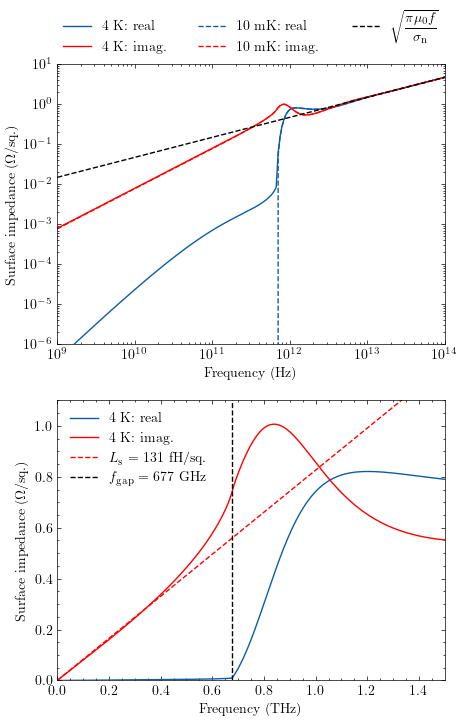

In [43]:
# Properties of the superconducting material, i.e., normal-state conductance,
# critical temperature, gap voltage at T=0K, and penetration depth
param = dict(sigma_n=1.74e7, Tc=8.1, Vgap0=2.65e-3, lambda0=86*sc.nano)

# Properties of the specific superconductor
d = 100e-9     # thickness of the superconducting film in [m]
T1 = 4.         # ambient temperature in [K]
T2 = 0.01       # ambient temperature in [K]
Vgap = 2.8e-3  # gap voltage at temperature T in [V]

fig, (ax1, ax2) = plt.subplots(2, figsize=(5,8))

# Frequency in [Hz]
f = np.logspace(9, 14, 201)

# Surface impedance [ohm / sq.]
Zs1 = mb.surface_impedance(f, d, T1, Vgap, **param)
Zs2 = mb.surface_impedance(f, d, T2, Vgap, **param)

# Plot results
ln, = ax1.loglog(f, Zs1.real, label='4 K: real')
ax1.loglog(f, Zs1.imag, 'r', label='4 K: imag.')
ax1.loglog(f, Zs2.real, label='10 mK: real', c=ln.get_color(), ls='--')
ax1.loglog(f, Zs2.imag, 'r--', label='10 mK: imag.')
ax1.loglog(f, np.sqrt(np.pi * sc.mu_0 * f / param['sigma_n']), 'k--', label=r'$\sqrt{\dfrac{\pi\mu_0f}{\sigma_\mathrm{n}}}$')
# ax1.loglog(f/1e9, np.sqrt(sc.mu_0 * (2 * np.pi * f) / 2 / 1.74e7), c=ln.get_color(), ls='--', label='Normal state')
# ax1.loglog(f/1e9, sc.mu_0 * (86*sc.nano) / np.tanh(d / 86 / sc.nano) * (2 * np.pi * f), 'r--', label="Surface inductance")

# Frequency in [Hz]
f = np.linspace(0, 1.5e12, 201)

# Surface impedance [ohm / sq.]
Zs1 = mb.surface_impedance(f, d, T1, Vgap, **param)

ax2.plot(f/1e12, Zs1.real, label='4 K: real')
ax2.plot(f/1e12, Zs1.imag, 'r', label='4 K: imag.')
ls = sc.mu_0 * (86*sc.nano) / np.tanh(d / 86 / sc.nano)
print(ls)
ax2.plot(f/1e12, sc.mu_0 * (86*sc.nano) / np.tanh(d / 86 / sc.nano) * (2 * np.pi * f), 'r--', label=r"$L_\mathrm{s}$" + f" = {ls/1e-15:.0f} fH/sq.")
fgap = Vgap * sc.e / sc.h
print(fgap)
ax2.axvline(fgap/1e12, c='k', ls='--', label=r'$f_\mathrm{gap}$' + f' = {fgap/1e9:.0f} GHz')

ax1.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
           mode="expand", borderaxespad=0, ncol=3, fontsize=10)
ax2.legend()
ax1.set(xlabel='Frequency (Hz)', xlim=[1e9, 1e14])
ax2.set(xlabel='Frequency (THz)', xlim=[0, f.max()/1e12])
ax1.set(ylabel=r'Surface impedance ($\Omega$/sq.)', ylim=[1e-6, 10])
ax2.set(ylabel=r'Surface impedance ($\Omega$/sq.)', ylim=[0, 1.1])
fig.savefig("superconductor-surface-impedance.png", dpi=400)